## 2 Whisper Baseline

This notebook will get the baseline WER and CER scores for Romansh. For this the test set each idiom will be decoded with both OpenAI's Whisper.

In [ ]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

import torch
from transformers import WhisperProcessor, WhisperForConditionalGeneration

from whisper_asr import transcribe_whisper, compute_wer_summary, plot_wer_comparison, load_all_data
from whisper_asr.utils import get_best_gpu

For now we will use the Whisper Medium, the constants can however be changed to use any other model.

In [4]:
WHISPER_MODEL = "medium"
BATCH_SIZE = 8

DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Selected GPU 6 with 24121 MiB free memory
Using device: cuda:6


First we load all the test data and concatenate it to one dataframe.

In [5]:
df_test = load_all_data("test")
print(f"\nTotal test samples: {len(df_test)}")
df_test.sample(10)


Total test samples: 631


,audio_path,sentence,idiom
429,../../romansh-data/rm-cc-2021-05-28/clips/5d03...,communala da Scuol ha decis da sanar la tschif...,RG
277,../../romansh-data/rmputer-cc-2021-06-11/clips...,L'otra regiun cun ün grand plus es Sedrun Ande...,Puter
465,../../romansh-data/rmvallader-cc-2021-05-28/cl...,"Dvantar polizista o polizis, l'interess d'eira...",Vallader
288,../../romansh-data/rmputer-cc-2021-06-11/clips...,Uschè es que eir gnieu cha mieu marus craja ch...,Puter
9,../../romansh-data/rmsurmiran-cc-2021-12-23/cl...,Per schlarger igl tratg tranter Silvaplana e S...,Surmiran
528,../../romansh-data/rmvallader-cc-2021-05-28/cl...,Stuvü imprender il tudais-ch e là ha'la quels ...,Vallader
378,../../romansh-data/rm-cc-2021-05-28/clips/5d03...,En la nova gulivaziun da finanzas duain tut la...,RG
418,../../romansh-data/rm-cc-2021-05-28/clips/5d03...,Passa 2 1000 7 100 persunas catolicas en Svizr...,RG
604,../../romansh-data/rmsursilv-cc-2021-05-28/cli...,Buca mo la scol'aulta separticipescha vid il c...,Sursilvan
317,../../romansh-data/rmputer-cc-2021-06-11/clips...,Ignorand la resposta cuorrane cun devoziun in ...,Puter


Then we can start transcribing with Whisper.

In [6]:
print("Loading Whisper model...")
processor = WhisperProcessor.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")
model = WhisperForConditionalGeneration.from_pretrained(f"openai/whisper-{WHISPER_MODEL}")

print("Transcribing with Whisper...")
whisper_transcriptions = transcribe_whisper(
    model=model,
    processor=processor,
    audio_paths=df_test["audio_path"].tolist(),
    batch_size=BATCH_SIZE,
    device=DEVICE
)

df_test['whisper_transcription'] = whisper_transcriptions
print("Whisper transcription complete.")

Loading Whisper model...


Loading weights: 100%|██████████| 947/947 [00:00<00:00, 4289.45it/s]


Transcribing with Whisper...


Transcribing (Whisper):   0%|          | 0/79 [00:00<?, ?it/s][transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generat

Whisper transcription complete.


Since Whisper is not trained on Romansh it is not surprising that the baseline scores are bad.

In [10]:
print("Computing Whisper WER summary...")
whisper_summary, df_results = compute_wer_summary(df_test, 'whisper_transcription')
print("\nWhisper WER Summary (%):")
print(whisper_summary.to_string(index=False))

Computing Whisper WER summary...



Whisper WER Summary (%):
    idiom  samples  wer_mean  wer_std
    Puter      114    102.61    41.20
       RG       81     92.66    30.24
 Surmiran      151    109.81    75.59
Sursilvan       94    100.64    22.27
Sutsilvan       94    107.85    46.79
 Vallader       97     99.49    25.25
  OVERALL      631    103.06    48.02


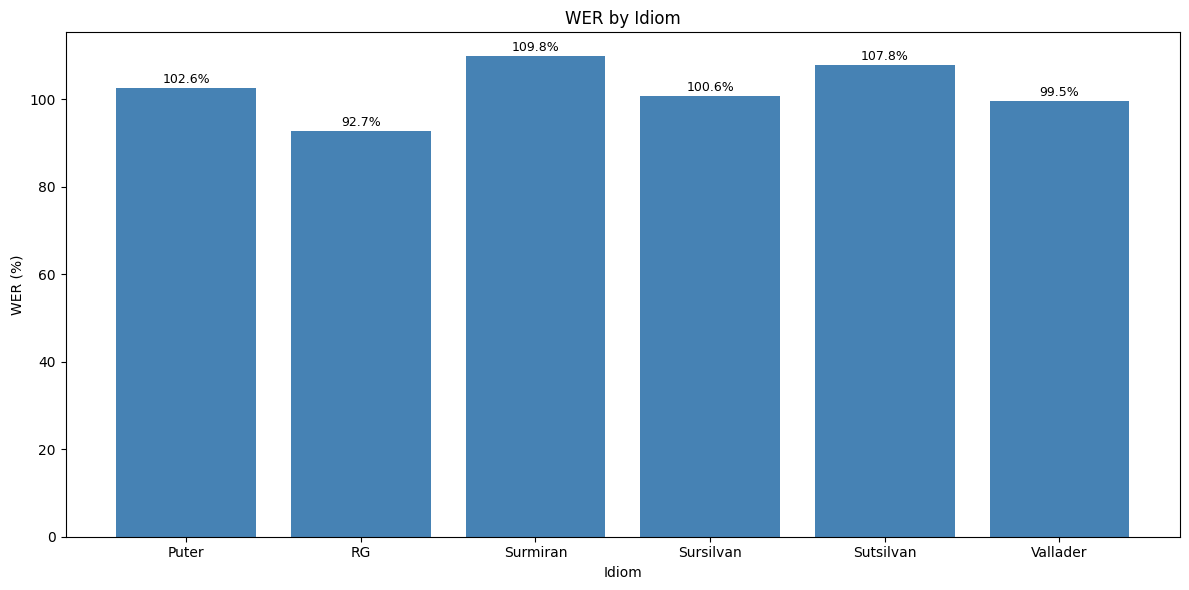

In [11]:
plot_wer_comparison(whisper_summary)

From the example transcriptions it becomes clear that Whisper is not trained on Romansh so it will just automatically detect a wrong language and then transcribe for that language.

In [12]:
print("\n" + "="*60)
print("EXAMPLE TRANSCRIPTIONS")
print("="*60)

sample_rows = df_results.sample(min(5, len(df_results)), random_state=42)
for idx, row in sample_rows.iterrows():
    print(f"\nIdiom: {row['idiom']}")
    print(f"Reference: {row['sentence'][:150]}...")
    print(f"Whisper: {row['whisper_transcription'][:150]}...")
    print(f"WER: {row['wer']*100:.1f}%, CER: {row['cer']*100:.1f}%")
    print("-" * 40)


EXAMPLE TRANSCRIPTIONS

Idiom: Vallader
Reference: Ma, quai es tuots duos listess important, la il plü decisiv es la fiduzcha....
Whisper:  Aber das ist das Wichtigste. Die Fiduzie ist das Wichtigste....
WER: 100.0%, CER: 74.7%
----------------------------------------

Idiom: Puter
Reference: E que es il cas. Perque ho la fundaziun premi grischun da litteratura decis da surder a Romana Ganzoni il premi grischun da litteratura da l'an 2 1000...
Whisper:  Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe Ḥe...
WER: 186.7%, CER: 84.6%
----------------------------------------

Idiom: Sutsilvan
Reference: Ad ear igl sunar, lez mànc'a mei ear. A mei par'igl qua fas anzatge ampo par l'olma, qua fas anzatge par te a quegl e anzatge bi da far. Ad a mei mànc...
Whisper:  Aga eri sunar, et maankamai er. Ma ei parei, kui ma fasin siin põrlool, ma fasin siin põrtei, aga kui siin bide far. Aga ma ei man